# Bike Sharing Demand예측 AI모델 개발

## 개요
- 시간대별 자전거 대여량 예측

## 분석 배경 
- 워싱턴 D.C 소재의 자전거 대여 스타트업인 Capital Bikeshare의 데이터를 활용
- 시간대별 자전거 대여량 예측함
- https://softeer.ai/practice?type=DA&page=0

## 평가 지표
- RMSLE : Root Mean Scaled Logarithmic Error
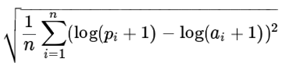

## 데이터 셋 정보


### [Data Files]
- (2011, 2012) 2년간 데이터
- train.csv: 학습용 데이터 (Features, Target) - 7,620건     
- test.csv:  예측용 데이터 (Features) - 3,266건

### [Feature]
- datetime: 자전거 대여가 일어난 년-월-일-시-분-초
- season: 계절
    – 1 = spring, 2 = summer, 3 = fall, 4 = winter
- holiday: 공휴일이면 1, 아니면 0
- workingday: 근무일이면 1, 아니면 0
- weather (날씨)
    - 1: Clear, Few clouds, Partly cloudy, Partly cloudy
    - 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
    - 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
    - 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp: 온도
- atemp: 체감온도
- humidity: 습도
- windspeed: 풍속

### [Target]
- count: (시간대별) 자건거 대여량
    - count = casual(비회원의 대여량) + registered(회원의 대여량)

## 분석 단계 
- **[step1] 라이브러리 및 데이터 불러오기** 
 - (1) 라이브러리 불러오기
 - (2) 데이터 불러오기 
 - (3) 데이터 확인 
 - (4) 데이터 타입 변환 (필요시)
- **[step2] 탐색적 데이터 분석 (EDA)**
 - (1) 기술적 통계분석
 - (2) 변수별 분포 시각화  
- **[step3] 데이터 전처리**
 - (1) 중복값 처리 **(Train셋만)**
 - (2) 불필요한 Feature삭제 (ID 등)
 - (3) 결측치 처리 
 - (4) 아웃라이어 제거 **(Train셋 & 양적변수만)**
 - (5) Feature, Target 설정
 - (6) 원핫 인코딩 **(feature-질적변수만)**
 - (7) 스케일링 **(feature-양적변수만)**
- **[step4] 모델 설계** 
 - (1) 훈련 및 검증 데이터 분할
 - (2) 평가지표 확인
 - (3) 알고리즘별 학습, 예측, 평가 
 - (4) 하이퍼파라미터 튜닝
- **[step5] 모델 선택 및 적용**
 - (1) test data의 예측값 생성
 - (2) 예측값 스케일 복구 (로그 변환 등으로 필요시)
- **[step6] 결과 파일 생성** 
 - (1) 예시 파일 불러오기 
 - (2) test data의 예측 결과 저장 
 - (3) 제출할 csv파일 생성

## [Step1] 불러오기
### (1) 라이브러리 불러오기

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# regression models

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [ ]:
from sklearn.model_selection import train_test_split  #학습셋과 검증셋 분리
from sklearn.model_selection import GridSearchCV  # 하이퍼파라미터 튜닝

### (2) 데이터 불러오기

**train data**

In [ ]:
#train set load
train = <blank>('./data/train.csv')
train

**test data**

In [ ]:
#test set load
test = pd.read_csv(<blank>)
test

### (3) 데이터 확인 
 - df.info()

In [ ]:
train.<blank>

- Column: 12개, 데이터 건수: 7620
- 모든 변수의 Non-Null Count 값이 7620 건으로 train data에 결측치가 없음
- **datetime**의 데이터 타입이 object(문자열)임

In [ ]:
test.<blank>

- Column: 12개, 데이터 건수: 3266
- 모든 변수의 Non-Null Count 값이 3266 건으로 test data에도 결측치가 없음
- **datetime**의 데이터 타입이 object(문자열)임

### (4) 데이터 타입 변환 
- **datetime**을 수치형 데이터 타입인 **datetime64**로 변환
- 년/월/일/시/분/초 형식의 **datetime64**로 변환해야 추후 분석이 용이함
    - 예를 들면, **년,월,일,시,분,초** 값을 각각 **분리**할 수 있음

#### train data

In [ ]:
#datetiem64 형식으로 변환
train['datetime'] = pd.to_datetime(train[<blank>])  

In [ ]:
#변환되었는지 확인
train.info()

- datetime64형 변수의 **dt 속성**을 이용, 년,월,일,시,분,초 값 분리
    - (ex: dt.year, dt.month)

In [ ]:
# 년,월,일,시,분,초 값 분리
train['year']=train['datetime'].dt.<blank>     # 1. 년도 추출 
train['month']=train['datetime'].dt.<blank>   # 2. 월 추출 
train['day']=train['datetime'].dt.<blank>       # 3. 일 추출 
train['hour']=train['datetime'].dt.<blank>     # 4. 시 추출 
train['minute']=train['datetime'].dt.<blank> # 5. 분 추출 
train['second']=train['datetime'].dt.<blank> # 6. 초 추출 
train['dayofweek']=train['datetime'].dt.<blank> #7. 요일 추출  (월요일:0, 일요일:6)

In [ ]:
# 결과 확인
print(train.shape)
train.head()

#### test data

In [ ]:
#datetiem64 형식으로 변환
test['datetime'] = pd.to_datetime(test['datetime'])  

In [ ]:
#변환되었는지 확인
test.info()

In [ ]:
# 년,월,일,시,분,초 값 분리
# 년,월,일,시,분,초 값 분리
test['year']=test['datetime'].dt.year # 년도 추출 
test['month']=test['datetime'].dt.month # 월도 추출 
test['day']=test['datetime'].dt.day # 일 추출 
test['hour']=test['datetime'].dt.hour # 시 추출 
test['minute']=test['datetime'].dt.minute # 분 추출 
test['second']=test['datetime'].dt.second # 초 추출 
test['dayofweek']=test['datetime'].dt.dayofweek #요일 추출 , 월요일:0, 일요일:6

In [ ]:
# 결과 확인
print(test.shape)
test.head()

## [Step2] 탐색적 데이터 분석 (EDA)

### (1) 기술통계분석
- describe()를 이용한 통계치 확인

In [ ]:
# 각 변수들의 기초 통계량 확인-train data
train.describe()

In [ ]:
# 각 변수들의 기초 통계량 확인-test data
test.describe()

#### [정리] 기술통계분석 결과에서
- 명목(카테고리) 변수의 경우 평균값 등이 의미가 없음! ==> 오히려 min, max를 통해 카테고리 값이 train과 test셋에 고르게 분포했는지 확인해야 함
    - season, holiday, weather, year, month, day, hour, minute, second, dayofweek
- **(중요)** weather의 경우
    - train셋: 1,2,3,4
    - test셋:  1,2,3
    - 이 경우 train셋과 test셋을 각각 one-hot 인코딩하면 **feature수가 달라지게 됨**
- 분과 초는 단일값 (0)으로 구성, 머신러닝에 도움이 되지 않음 
    - feature로 사용하지 않음, 삭제 예정
- casual과 registered를 count를 구성하는 값으로 train셋에만 있음 
    - feature로 사용하지 않음, 삭제 예정

[추가확인-weather]

In [ ]:
train["weather"].value_counts()

In [ ]:
test["weather"].value_counts()

### (2) 변수별 분포 시각화 

#### 1) 변수들간 상관관계를 보여주는 pairplot

In [ ]:
# pairplot -변수간 상관관계 확인

# 주요 변수만 추출하여 pairplot
train_var=train[["season","workingday","weather","temp","humidity","windspeed","count","year","month","day","hour"]]

plt.figure(figsize = (15,15))
sns.<blank>(train_var)
plt.show()

#### [정리] pairplotting을 해 보면,
- 변수의 형태에 따라서 산점도 양상이 달라짐
    - (연속형-연속형), (연속형-범주형), (범주형-범주형)
- 특히 target변수(count)와 feature와의 관계를 유심히 관찰
    - 'day'변수의 경우 유의미한 관계가 잘 보이지 않음
    - 확인을 위해 count와 년/월/일/시 변수의 산점도를 확대하여 볼 수 있도록 다시 작성해봄

In [ ]:
# count와 년/월/일/시 변수의 산점도

fig,ax=plt.subplots(nrows=2, ncols=2, figsize=(15,8))

sns.scatterplot(x=train["year"],y=train["count"],data=train, ax=ax[0][0])
sns.scatterplot(x=train["month"],y=train["count"],data=train, ax=ax[0][1])
sns.scatterplot(x=train["day"],y=train["count"],data=train, ax=ax[1][0])
sns.scatterplot(x=train["hour"],y=train["count"],data=train, ax=ax[1][1])

plt.show()

##### [결론] target에 유의미한 상관성을 보이지 않는 day 변수 제거 
- 이후에 다른 변수와 함께 수행

- pairplot의 **대각선**을 따라서는 **개별 변수 분포도**가 제시됨
    - **연속형 변수: histplot 또는 distplot(histogram )**
        - feature - temp, atemp, humidity, windspeed
        - target - count
    - **범주형 변수: countplot**
        - season, workingday, weather, year, month, hour   

#### 2) 연속형(양적) 변수의 분포를 보여주는 histplot 

In [ ]:
# feature

fig, axes = plt.subplots(2, 2, figsize=(20,10))

sns.histplot(x = train['temp'], ax=axes[0][0])
sns.histplot(x = train['atemp'],ax=axes[0][1])
sns.histplot(x = train['humidity'],ax=axes[1][0])
sns.histplot(x = train['windspeed'],ax=axes[1][1])

plt.show()

#### [Target] 
- target값의 **로그 변환** 필요성 검토

In [ ]:
# target값의 원데이터와 로그변환데이터의 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.histplot(x = train['count'], ax=axes[0])
sns.histplot(x = np.<blank>(train['count']), ax=axes[1])

- 로그 변환 후, 분포 왜곡도가 완화됨을 알 수 있음

- [참고] np.log1p(x)함수
    - log(x+1)을 return함

### [참고] 로그 함수의 특징
- 밀집되어 있는 데이터는 퍼지게, 퍼진 데이터는 밀집되게 하여 원본의 분포왜곡을 완화

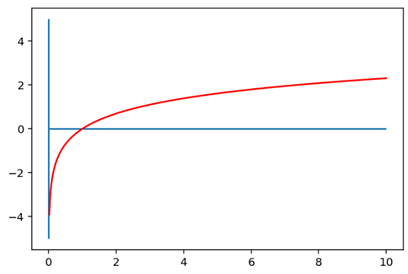

- 0<x<1 
    - 로그 변환후 (-무한대<y<0)의 범위로 분산됨 
    - 즉 제한된 범위의 x는 로그 변환 후 큰 범위로 벌어짐
- x>1
    - 로그 변환후 (0<y<특정값)의 범위로 제한됨 
    - 즉 넓은 범위의 x는 로그 변환후 범위가 제한됨

#### 3) 범주형 (질적) 변수의 빈도를 보여주는 countplot

In [ ]:
# countplot - 범주형 변수의 분포확인
columns = ['season', 'holiday', 'workingday', 'weather', 'year','month', 'hour', 'dayofweek']

fig, axes = plt.subplots(2, 4, figsize=(20,10))

for col_, ax_ in <blank>(columns, axes.<blank>):
    sns.countplot(data=train, x=col_, ax=ax_)
    
plt.show()

## [step3] 데이터 전처리

### (1) 중복값 처리 **(Train셋만)**

In [ ]:
# train 셋의 중복값의 총갯수 확인
train.duplicated().<blank>

#### 만약 train data 에 중복값이 있다면?
- df.drop_duplicates()를 이용하여 중복행을 제거

In [ ]:
#중복행이 존재하는 train2를 임의로 생성
temp=train[0:2]
train2 = train.copy()
train2=pd.concat([train2, temp])
train2

In [ ]:
train2.duplicated()

In [ ]:
#중복행 제거 - 앞쪽을 유지, 뒷쪽을 삭제
train2.<blank>(keep='first', ignore_index=True)

In [ ]:
#중복행 제거 - 뒷쪽을 유지, 앞쪽을 삭제
train2.drop_duplicates(keep=<blank>, inplace=True)
train2

In [ ]:
train2.duplicated()

### (2) 불필요한 Feature 삭제

In [ ]:
# train set
train.drop(['datetime', 'day', 'minute','second','casual', 'registered'], 
           axis=1, inplace=True)
train.head()

In [ ]:
# test set


### (3) 결측치 처리

- df.info()를 통해 train과 test 데이터에 결측치가 없음을 이미 확인 했음
- 추가적으로 아래 방법으로도 확인 가능

In [ ]:
#train셋
train.isnull().<blank>

In [ ]:
#test셋
test.<blank>.sum()

#### [정리] 만약 결측값이 있다면?
- df.fillna()를 이용하여 결측값을 채움

In [ ]:
# train2를 생성, 일부 field를 결측값으로 변경
train2 = train.copy()
train2.loc[0, 'temp'] = np.nan
train2.loc[1, 'atemp'] = np.<blank>

In [ ]:
# 결측값을 0으로 채우기
train3=train2.<blank>(0)
train3.head()

In [ ]:
# 결측값을 해당 column 평균값으로 채우기
train3=train2.fillna(train2.<blank>)
train3.head()

### (4) 아웃라이어 제거 **(Train셋 & 양적변수만)**
- target값을 기준으로 아웃라이어제거
- train셋에만 해당

In [ ]:
# boxplotting을 통해 outlier 존재여부 확인
plt.figure(figsize=(3,5))
sns.<blank>(y="count",data=train)   
plt.show()

- 아웃라이어 제거 방법
    - 1) 사분위수 범위(IQR = Q3-Q1)을 계산
    - 2) **Q1-1.5IQR**과 **Q3+1.5IQR**을 각각 max와 min으로 설정
    - 3) [min, max]를 벗어나는 데이터는 아웃라이어로 간주하여 제거

- target의 아웃라이어를 삭제하는 상기의 작업을 수행하지 않음
- 모델을 왜곡시키는 극단치라기 보다는 자연스러운 데이터로 간주

### (5) Feature, Target 설정
- train 셋: Feature / Target 으로 분리
- test 셋: Feature만 설정

In [ ]:
# train set - features 설정
Xtrain=<blank>
Xtrain

In [ ]:
# train set -- target 설정
ytrain=<blank>
ytrain

In [ ]:
# test set - features
Xtest=<blank>
Xtest

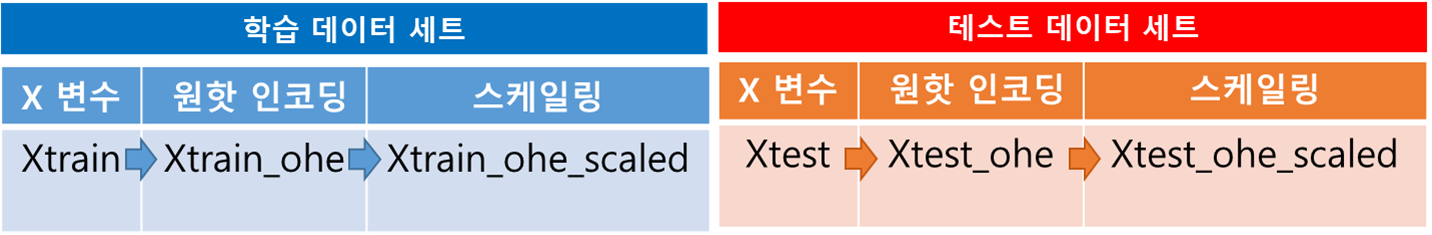

#### [중요] 만약 범주형데이터가 train셋과 test셋에 다르게 존재한다면 어떻게 될까?
- Xtrain["weather"]: 4개의 범주값
- Xtest["weather"]: 3개의 범주값

#### 이 경우 train셋과 test셋이 다르게 인코딩 될 수 있으므로 **합쳐서** 한꺼번에 인코딩!
    - train셋과 test셋 합치기: Xconcat
        - Xtrain: 0~7619(7,620개)
        - Xtest:  0~3265(3,266개)
    - Xconcat으로 총 10,886개 행의 (7,620개+3,266개) df 생성

In [ ]:
Xconcat = pd.<blank>([Xtrain, Xtest])
Xconcat

### (6) 원핫 인코딩 **(feature-질적변수만)**
- pd.get_dummies(df, columns=[해당 column명])
- 
- 범주형 변수에 대해서 수행

In [ ]:
Xconcat_ohe = pd.<blank>(Xconcat, 
                         columns = ['year', 'month', 'hour','holiday', 'dayofweek', 'workingday','weather','season'])
Xconcat_ohe

In [ ]:
print(Xtrain.shape)
print(Xtrain.shape[0])   
# Xtrain.shape[0] - 행의수, Xtrain.shape[1] - 열의 수

In [ ]:
Xtrain_ohe=Xconcat_ohe[<blank>]
Xtrain_ohe

In [ ]:
Xtest_ohe=Xconcat_ohe[<blank>]
Xtest_ohe

- 원핫 인코딩 이후 feature 증가

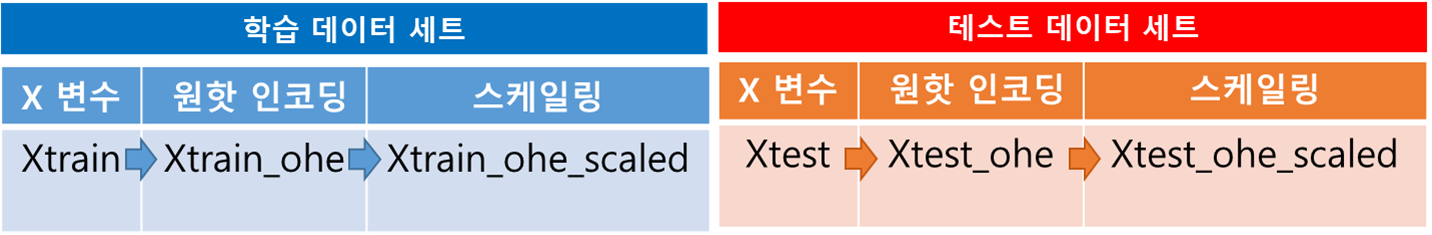

### (7) 스케일링 **(feature-양적변수만)**
- 스케일링을 통해 변수들의 데이터 분포나 범위를 조정

**[주의] 스케일링 시 주의사항**
- fit (스케일링을 위한 계산 수행): train data
- transform(적용): train data & test data 

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#object 선언
standard_scaler = <blank>
minmax_scaler= <blank>

- train 셋

In [ ]:
Xtrain_ohe_scaled=Xtrain_ohe.copy()
Xtrain_ohe_scaled

In [ ]:
Xtrain_ohe_scaled[['temp','atemp','humidity']]=\
<blank>.fit_transform(Xtrain_ohe[['temp','atemp','humidity']])

Xtrain_ohe_scaled[['windspeed']]=\
<blank>.fit_transform(Xtrain_ohe[['windspeed']])

Xtrain_ohe_scaled  #스케일링 결과 확인

- test 셋

In [ ]:
Xtest_ohe_scaled=Xtest_ohe.copy()
Xtest_ohe_scaled

In [ ]:
Xtest_ohe_scaled[['temp','atemp','humidity']]=\
standard_scaler.<blank>(Xtest_ohe[['temp','atemp','humidity']])

Xtest_ohe_scaled[['windspeed']]=\
minmax_scaler.<blank>(Xtest_ohe[['windspeed']])

Xtest_ohe_scaled  #스케일링 결과 확인

In [ ]:
Xtest_ohe_scaled.min()

In [ ]:
Xtest_ohe_scaled.max()

##### target 로그 변환
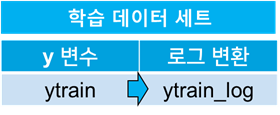

In [ ]:
ytrain_log = <blank>

In [ ]:
# 로그 변환 후 scale down됨 -ytrain_log의 최대값 확인
ytrain_log.<blank>

## [step4] 모델 설계 
 - 모델의 선택 및 학습, 예측, 평가 분석 모델 설계
 - 다양한 모델의 성능비교 실시 
    - 선형 모델 - LinearRegression 
    - 트리기반 회귀모델 - DecisionTreeRegressor
    - 트리기반 앙상블 모델 (배깅 기법) - RandomForestRegressor, ExtraTreesRegressor
    - 트리기반 앙상블 모델 (부스팅 기법) - XGBRegressor, LGBMRegressor

- 성능을 평가하기 위해 학습 데이터셋에서 20%를 활용해 검증 데이터셋을 생성
 - test_size = 0.2
 - random_state = 0

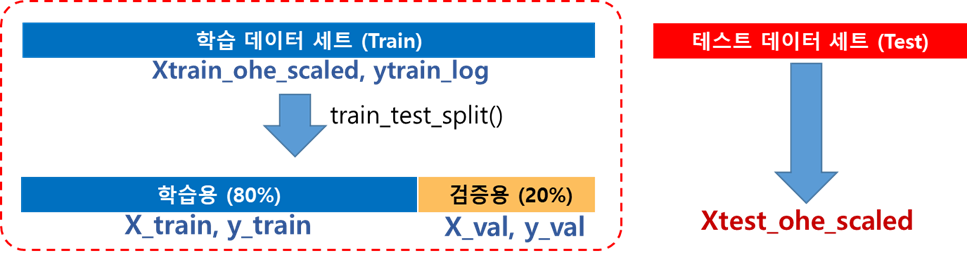

### (1) 훈련 및 검증 데이터 분할

In [ ]:
# 데이터 분할: test_size=0.2, random_state=0

X_train, X_val, y_train, y_val = train_test_split(Xtrain_ohe_scaled, 
                                                  ytrain_log, 
                                                  test_size=0.2, 
                                                  random_state=0)

### (2) 평가지표 확인
- 평가지표가 RMSLE이므로 해당 함수를 작성해야 함

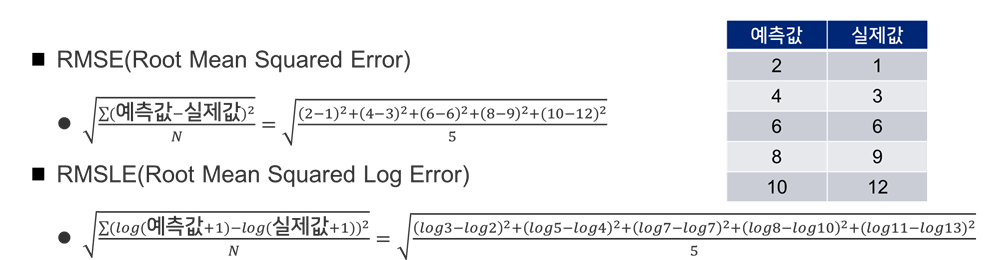

In [ ]:
#실제값과 예측값의 log(x+1)값을 입력값으로 root_mean_scared_error를 구하는 함수 작성

def rmsle(log1p_actual, log1p_pred):
    squared_error = (<blank>-<blank>)**2   
    return np.<blank>(np.<blank>(squared_error))

### (3) 알고리즘별 학습, 예측, 평가 

In [ ]:
# for문을 이용하여 작성
# 1) Linear Regression ~ 6) LGBM Regressor

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(n_jobs=-1),
    'Extra Trees Regressor': ExtraTreesRegressor(n_jobs=-1),
    'XGB Regressor' : XGBRegressor(verbose=-1,n_jobs=-1),
    'LGBM Regressor' : LGBMRegressor(verbose=-1,n_jobs=-1)
}

# 초기화: selected_estimator, pre_rmsle
selected_estimator = None
min_rmsle = float('inf')

# 모델 학습 및 평가
for name, estimator in models.items():    
    <blank>.fit(X_train, y_train)
    pred = <blank>.predict(X_val)
    rmsle_ = rmsle(y_val, pred)
    print(f'[{<blank>} 모델의 rmsle ]: {round(rmsle_, 3)}')

    if rmsle_ < min_rmsle:
        selected_estimator = <blank>
        min_rmsle = <blank>
        print(f'selected estimator: {<blank>}')
    print('')

**[정리] 가장 성능이 좋은 모델을 최종 선정** 

### (4) 하이퍼 파라미터 튜닝

[사용자 정의 함수로 scoring 하는 방법]
- bike예제의 rmsle처럼 사용자 정의 함수를 사용할 경우 다음과 같이 make_scorer()함수를 활용한다.
    - scoring=**make_scorer(사용자정의 함수명, greater_is_better=True(default))**
        - 회귀모델의 error지표라면 **greater_is_better=False**

    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html#sklearn.metrics.make_scorer

- 튜닝전에, default parameter일때의 성능을 Cross Validation 기반 재검증

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# 1) (Cross Validation이 목적이므로) 파라미터 설정은 하지 않음
parameters ={}

# 2) GridSearchCV 설정: 
grid_reg = GridSearchCV(selected_estimator, 
                        parameters,                        
                        scoring=make_scorer(rmsle),
                        cv=5)

# 3) GridSearchCV estimator로 학습: 
grid_reg.fit(Xtrain_ohe_scaled, ytrain_log)

# 4) Score확인
print('교차 검증 score: ', grid_reg.best_score_)

- 실제 하이퍼파라미터 튜닝 시작!

In [ ]:
# 1) 파라미터 후보군 설정
# 많은 하이퍼파라미터를 대상으로 진행할 수 있지만, 파라미터를 생략하고 진행해도 됨.
# 그러면 default parameter를 사용한 Cross Validation 효과가 나타남
#parameters ={} 

parameters ={'n_estimators' : [100,500] }
cv_=5

In [ ]:
# 2) GridSearchCV 설정: 사용자정의 함수로 scoring 
grid_reg = GridSearchCV(<balnk>, 
                        parameters, 
                        scoring=make_scorer(rmsle, greater_is_better=False),
                        cv=cv_) 

In [ ]:
# 3) GridSearchCV estimator로 학습: 
grid_reg.fit(<blank>,<blank>)  #전체 데이터셋으로 fit

In [ ]:
# 4) GridSearchCV 결과 확인
print('최적 하이퍼 파라미터 : ', grid_reg.best_params_)

In [ ]:
# 5) GridSearchCV score 확인
print('최적 하이퍼 파라미터 score: ', -1*grid_reg.best_score_)

- 단 greater_is_better=Fals 일 경우, score는 negative로 표시됨
    - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html#sklearn.metrics.make_scorer
    - make_scorer(greater_is_better=False)
        - Whether score_func is a score function (default), meaning high is good, or a loss function, meaning low is good. In the latter case, **the scorer object will sign-flip the outcome of the score_func**.

## [step5] 모델 선택 및 적용
### (1) test data의 예측값 생성 
- 선정된 최고 성능의 모델로 test data 예측

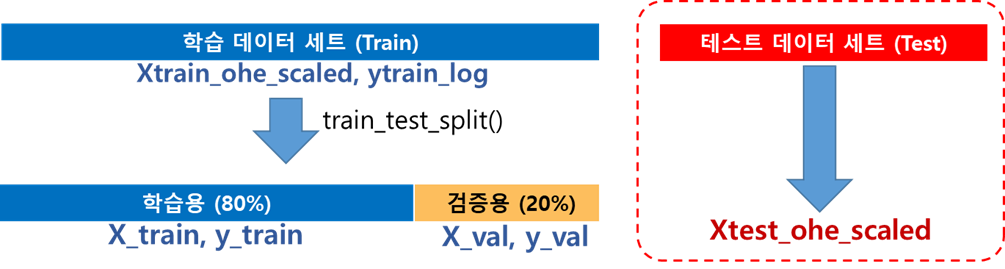

In [ ]:
pred_test = <blank>.predict(<blank>)

In [ ]:
pred_test

### (2) 예측값 스케일 복구 (로그 변환 등으로 필요시)

In [ ]:
pred_test =np.<blank>(pred_test)
pred_test

### (3) 실제값과 예측값의 분포 비교

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.histplot(x=ytrain, ax=axes[0]) # 실제값 
sns.histplot(x=pred_test, ax=axes[1])  # 예측값
plt.show()

- target의 실제값과 예측값의 분포가 유사함을 확인

## [step6] 결과 파일 생성 
### (1) 예시 파일 불러오기 

In [ ]:
#예시 파일 불러오기
submission = pd.read_csv('./data/sampleSubmission.csv')
submission.head(5)

### (2) 예측 결과 저장

In [ ]:
#test data의 예측 결과 저장하기
submission['count'] = <blank>
submission.head(5)

### (3) 제출할 csv파일 생성

In [ ]:
#제출 파일 생성하기
submission.<blank>('./data/MySubmission.csv', index=False)

**수고하셨습니다** 

[현재 모델에서 feature_importance를 확인]

In [ ]:
# 튜닝전 모델
pd.DataFrame(data=selected_estimator.feature_importances_, 
             index=selected_estimator.feature_name_,
             columns=['중요도']).sort_values(by=['중요도'], ascending=False)

In [ ]:
# 튜닝후 모델
pd.DataFrame(data=grid_reg.best_estimator_.feature_importances_, 
             index= grid_reg.best_estimator_.feature_name_ ,
             columns=['중요도']).sort_values(by=['중요도'], ascending=False)

In [ ]:
sns.boxplot(data=Xtrain[["humidity","temp"]])
plt.show()

In [ ]:
pd.set_option('display.max_rows', 100)  # 100개까지 다 보겠다
print(Xtrain['humidity'].value_counts())  #0인 데이터가 18개

- Xtrain['humidity']==0 인 데이터를 제외하고 (아웃라이어 제거) 다시 분석하고 싶다면?